In [ ]:
import subprocess, sys
try:
    import open_mythos  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "open-mythos"])

import math, time, copy
from collections import Counter, defaultdict

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

from open_mythos.main import (
    OpenMythos, MythosConfig,
    ACTHalting, MoEFFN,
)

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"▸ device = {device}   |   torch = {torch.__version__}")

def make_config(attn_type: str, *, dim=128, n_heads=4, n_experts=4,
                max_loops=8, seq_len=128, vocab=256):
    base = dict(
        vocab_size=vocab, dim=dim, n_heads=n_heads,
        max_seq_len=seq_len, max_loop_iters=max_loops,
        prelude_layers=1, coda_layers=1,
        n_experts=n_experts, n_shared_experts=1,
        n_experts_per_tok=2, expert_dim=dim // 2,
        lora_rank=8, attn_type=attn_type,
    )
    if attn_type == "gqa":
        return MythosConfig(**base, n_kv_heads=2)
    return MythosConfig(
        **base, n_kv_heads=n_heads,
        kv_lora_rank=32, q_lora_rank=64,
        qk_rope_head_dim=16, qk_nope_head_dim=16, v_head_dim=16,
    )

cfg_gqa = make_config("gqa")
cfg_mla = make_config("mla")
m_gqa = OpenMythos(cfg_gqa).to(device)
m_mla = OpenMythos(cfg_mla).to(device)

print("\n─── Part 1 ─ model sizes ──────────────────────────────")
print(f"GQA  params : {sum(p.numel() for p in m_gqa.parameters()):>10,}")
print(f"MLA  params : {sum(p.numel() for p in m_mla.parameters()):>10,}")

In [ ]:
def cache_bytes(kv: dict) -> int:
    total = 0
    for entry in kv.values():
        for t in entry.values():
            total += t.element_size() * t.numel()
    return total

x = torch.randint(0, 256, (1, 64), device=device)
ck_gqa, ck_mla = {}, {}
with torch.no_grad():
    m_gqa(x, n_loops=4, kv_cache=ck_gqa)
    m_mla(x, n_loops=4, kv_cache=ck_mla)

gqa_kb = cache_bytes(ck_gqa) / 1024
mla_kb = cache_bytes(ck_mla) / 1024
print("\n─── Part 2 ─ KV-cache footprint (1×64 tokens, 4 loops) ─")
print(f"GQA cache : {gqa_kb:6.2f} KB   ({len(ck_gqa)} layer-keys)")
print(f"MLA cache : {mla_kb:6.2f} KB   ({len(ck_mla)} layer-keys)")
print(f"ratio      : MLA is ≈{gqa_kb / max(mla_kb, 1e-9):.2f}× smaller")

def show_stability(model, tag):
    A = model.recurrent.injection.get_A()
    print(f"{tag:3s}  ρ(A): min={A.min():.4f}  max={A.max():.4f}  "
          f"mean={A.mean():.4f}  stable={bool((A < 1).all() and (A > 0).all())}")

print("\n─── Part 3 ─ spectral radius at init ──────────────────")
show_stability(m_gqa, "GQA")
show_stability(m_mla, "MLA")

opt = torch.optim.Adam(m_mla.parameters(), lr=1.0)
for _ in range(30):
    loss = m_mla(torch.randint(0, 256, (2, 16), device=device),
                 n_loops=2).square().mean()
    opt.zero_grad(); loss.backward(); opt.step()
show_stability(m_mla, "MLA after abusive training (lr=1.0, 30 steps)")

In [ ]:
VOCAB = 64
SEQ_LEN = 24

def make_batch(batch=64, seq_len=SEQ_LEN):
    x = torch.randint(1, 3, (batch, seq_len), device=device)
    bits = x - 1
    parity = bits.cumsum(dim=1) % 2
    y = parity + 1
    return x, y

cfg = MythosConfig(
    vocab_size=VOCAB, dim=64, n_heads=4, n_kv_heads=2,
    max_seq_len=SEQ_LEN + 4, max_loop_iters=16,
    prelude_layers=1, coda_layers=1,
    n_experts=4, n_shared_experts=1, n_experts_per_tok=2,
    expert_dim=32, lora_rank=4, attn_type="gqa",
    act_threshold=0.99,
)
model = OpenMythos(cfg).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
T_TRAIN = 3

print("\n─── Part 5 ─ training (T_train = 3) ───────────────────")
print(f"params: {sum(p.numel() for p in model.parameters()):,}")
losses = []
t0 = time.time()
for step in range(600):
    x, y = make_batch(64)
    logits = model(x, n_loops=T_TRAIN)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if step % 100 == 0 or step == 599:
        with torch.no_grad():
            acc = (logits.argmax(-1) == y).float().mean().item()
        print(f"step {step:3d}   loss={loss.item():.4f}   acc@T3={acc:.3f}")
print(f"training wallclock: {time.time() - t0:.1f}s")

In [ ]:
model.eval()
T_sweep = [1, 2, 3, 4, 6, 8, 10, 12, 14, 16]
accs = []
with torch.no_grad():
    x_eval, y_eval = make_batch(512)
    for T in T_sweep:
        logits = model(x_eval, n_loops=T)
        accs.append((logits.argmax(-1) == y_eval).float().mean().item())

print("\n─── Part 6 ─ depth extrapolation (T_train=3) ──────────")
for T, a in zip(T_sweep, accs):
    bar = "█" * int(a * 40)
    marker = "  ← trained here" if T == T_TRAIN else ""
    print(f"T={T:2d}  acc={a:.3f}  {bar}{marker}")

halt_trace: list[torch.Tensor] = []
orig_halt = model.recurrent.act.forward

def halt_hook(self, h):
    p = orig_halt(h)
    halt_trace.append(p.detach().cpu())
    return p
model.recurrent.act.forward = halt_hook.__get__(model.recurrent.act, ACTHalting)

with torch.no_grad():
    x_h, _ = make_batch(1)
    _ = model(x_h, n_loops=16)

model.recurrent.act.forward = orig_halt

halts = torch.stack(halt_trace, dim=0)[:, 0].numpy()
print(f"\n─── Part 7 ─ ACT halting matrix (loops × positions) ───")
print(f"shape: {halts.shape}  |  "
      f"mean halt-prob per loop: "
      f"{', '.join(f'{v:.2f}' for v in halts.mean(1))}")

▸ device = cpu   |   torch = 2.11.0+cu130

─── Part 1 ─ model sizes ──────────────────────────────
GQA  params :    462,274
MLA  params :    419,554

─── Part 2 ─ KV-cache footprint (1×64 tokens, 4 loops) ─
GQA cache : 192.00 KB   (6 layer-keys)
MLA cache : 144.00 KB   (6 layer-keys)
ratio      : MLA is ≈1.33× smaller

─── Part 3 ─ spectral radius at init ──────────────────
GQA  ρ(A): min=0.3679  max=0.3679  mean=0.3679  stable=True
MLA  ρ(A): min=0.3679  max=0.3679  mean=0.3679  stable=True
MLA after abusive training (lr=1.0, 30 steps)  ρ(A): min=0.0000  max=0.8515  mean=0.1167  stable=False

─── Part 5 ─ training (T_train = 3) ───────────────────
params: 112,002
step   0   loss=4.0939   acc@T3=0.000
step 100   loss=0.8883   acc@T3=0.506
step 200   loss=0.7054   acc@T3=0.513
step 300   loss=0.6859   acc@T3=0.529
step 400   loss=0.6723   acc@T3=0.512
step 500   loss=0.6569   acc@T3=0.549
step 599   loss=0.6427   acc@T3=0.550
training wallclock: 70.2s

─── Part 6 ─ depth extrapolation (

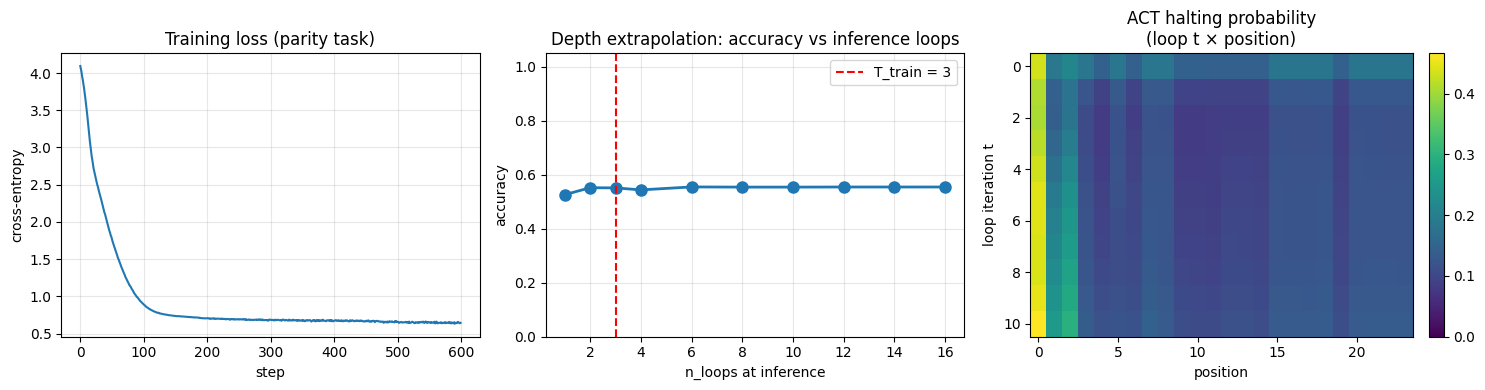

In [1]:
expert_hits = Counter()
orig_moe = model.recurrent.block.ffn.forward

def moe_hook(self, x):
    flat = x.view(-1, x.shape[-1])
    logits = self.router(flat) + self.router_bias
    scores = F.softmax(logits, dim=-1)
    _, idx = scores.topk(self.topk, dim=-1)
    for e in idx.flatten().tolist():
        expert_hits[e] += 1
    return orig_moe(x)

model.recurrent.block.ffn.forward = moe_hook.__get__(
    model.recurrent.block.ffn, MoEFFN)

with torch.no_grad():
    x_m, _ = make_batch(32)
    _ = model(x_m, n_loops=T_TRAIN)

model.recurrent.block.ffn.forward = orig_moe

print("\n─── Part 8 ─ MoE expert utilization ───────────────────")
total = sum(expert_hits.values())
for eid in range(cfg.n_experts):
    share = expert_hits.get(eid, 0) / max(total, 1)
    print(f"expert {eid}: {share*100:5.2f}% of topk slots")

prompt = torch.tensor([[1, 2, 1, 1, 2, 2, 1, 2]], device=device)
print("\n─── Part 9 ─ generation ───────────────────────────────")
print(f"prompt (parity pattern): {prompt.tolist()[0]}")
for T_gen in [1, 4, 12]:
    with torch.no_grad():
        out = model.generate(prompt, max_new_tokens=8,
                             n_loops=T_gen, temperature=0.1, top_k=2)
    print(f"T_gen={T_gen:2d}  → {out.tolist()[0]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses)
axes[0].set_title("Training loss (parity task)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("cross-entropy")
axes[0].grid(alpha=0.3)

axes[1].plot(T_sweep, accs, "o-", linewidth=2, markersize=8)
axes[1].axvline(T_TRAIN, color="red", linestyle="--",
                label=f"T_train = {T_TRAIN}")
axes[1].set_title("Depth extrapolation: accuracy vs inference loops")
axes[1].set_xlabel("n_loops at inference"); axes[1].set_ylabel("accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1.05)

im = axes[2].imshow(halts, aspect="auto", cmap="viridis",
                    vmin=0, vmax=halts.max())
axes[2].set_title("ACT halting probability\n(loop t × position)")
axes[2].set_xlabel("position"); axes[2].set_ylabel("loop iteration t")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("openmythos_tutorial.png", dpi=120, bbox_inches="tight")
plt.show()